In [145]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [146]:
pd.set_option('display.max_rows',None)
pd.set_option('display.max_colwidth',None)

In [147]:
df=pd.read_csv(r"C:\Users\naren\Desktop\petro\petro\analytics\projects\sms spam detection\spam.csv",encoding='latin1')

In [148]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives around here though",NaN,NaN,NaN


## steps
* data cleaning
* eda
* text preprocessing
* model building
* evaluation
* improvement
* website
* deploy

## **1.Data cleaning**

In [149]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [150]:
df['Unnamed: 4'].value_counts()

Unnamed: 4
GNT:-)"                                                     2
 just Keep-in-touch\" gdeve.."                              1
 Never comfort me with a lie\" gud ni8 and sweet dreams"    1
 CALL 2MWEN IM BK FRMCLOUD 9! J X\""                        1
 one day these two will become FREINDS FOREVER!"            1
Name: count, dtype: int64

In [151]:
df['Unnamed: 3'].value_counts()

Unnamed: 3
 MK17 92H. 450Ppw 16"                         2
GE                                            2
 why to miss them                             1
U NO THECD ISV.IMPORTANT TOME 4 2MORO\""      1
i wil tolerat.bcs ur my someone..... But      1
 ILLSPEAK 2 U2MORO WEN IM NOT ASLEEP...\""    1
whoever is the KING\"!... Gud nyt"            1
 TX 4 FONIN HON                               1
 \"OH No! COMPETITION\". Who knew             1
IåÕL CALL U\""                                1
Name: count, dtype: int64

In [152]:
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)

In [153]:
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives around here though"


In [154]:
df.rename(columns={'v1':'target','v2':'text'},inplace=True)

In [155]:
from sklearn.preprocessing import LabelEncoder
en = LabelEncoder()

In [156]:
df['target']=en.fit_transform(df['target'])

In [157]:
# ham-->0
# spam-->1
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives around here though"


In [158]:
# missing value check
df.isnull().sum()

target    0
text      0
dtype: int64

In [159]:
# duplicate check
df.duplicated().sum()

np.int64(403)

In [160]:
df.drop_duplicates(keep='first',inplace=True)

In [161]:
df.duplicated().sum()

np.int64(0)

In [162]:
df.shape

(5169, 2)

## *EDA*

In [163]:
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

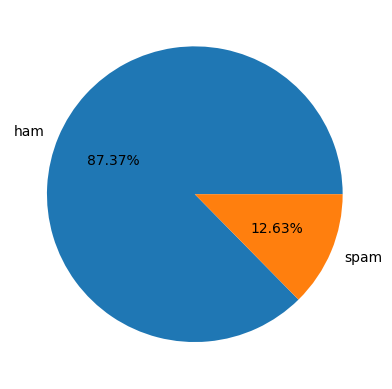

In [164]:
plt.pie(df['target'].value_counts(),labels=['ham','spam'],autopct='%.2f%%')
plt.show()

In [165]:
# imbalance data

In [166]:
import nltk

In [167]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\naren\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [168]:
# no of chars in each sentence
df['num_chars']=df['text'].apply(len)

In [169]:
df.head()

,target,text,num_chars
0,0,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives around here though",61


In [170]:
# no of words in each sentence
df['num_words']=df['text'].apply(lambda x:len(nltk.word_tokenize(x)))

In [171]:
df.head()

,target,text,num_chars,num_words
0,0,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives around here though",61,15


In [172]:
# no of sentences in each text document
df['num_sentence']=df['text'].apply(lambda x : len(nltk.sent_tokenize(x)))

In [173]:
df.head()

,target,text,num_chars,num_words,num_sentence
0,0,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives around here though",61,15,1


In [174]:
# ham
df[df['target']==0][['num_chars','num_words','num_sentence']].describe()

,num_chars,num_words,num_sentence
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [175]:
#spam
df[df['target']==1][['num_chars','num_words','num_sentence']].describe()

,num_chars,num_words,num_sentence
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


<Axes: xlabel='num_chars', ylabel='Count'>

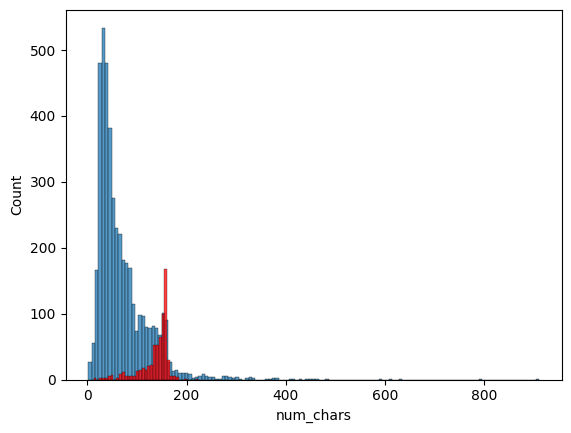

In [176]:
sns.histplot(df[df['target']==0]['num_chars'])
sns.histplot(df[df['target']==1]['num_chars'],color='red')

<Axes: xlabel='num_words', ylabel='Count'>

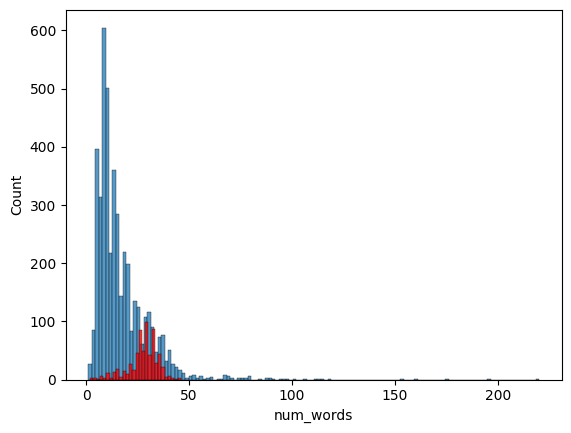

In [177]:
sns.histplot(df[df['target']==0]['num_words'])
sns.histplot(df[df['target']==1]['num_words'],color='red')

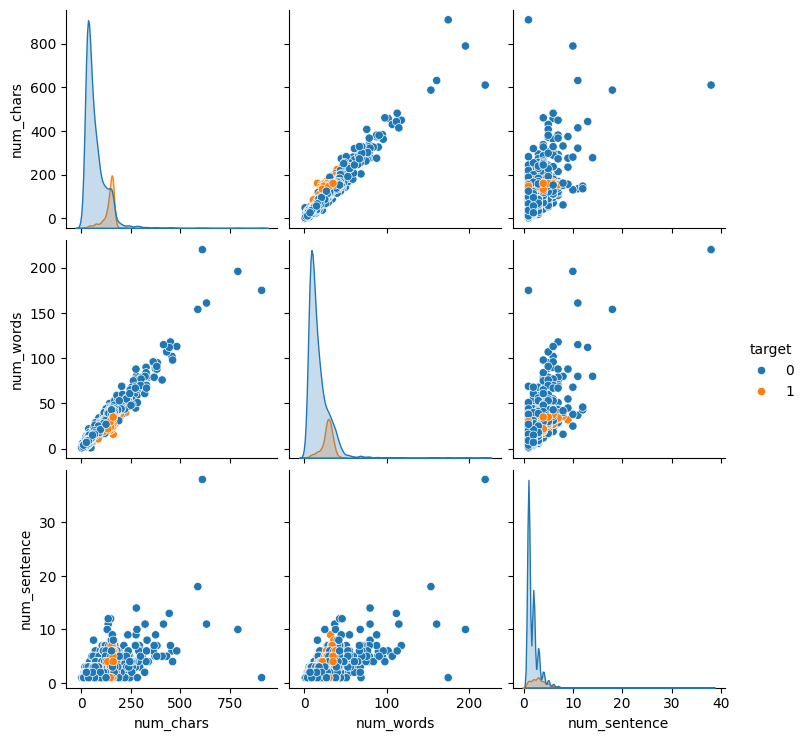

In [178]:
sns.pairplot(df,hue='target')

<Axes: >

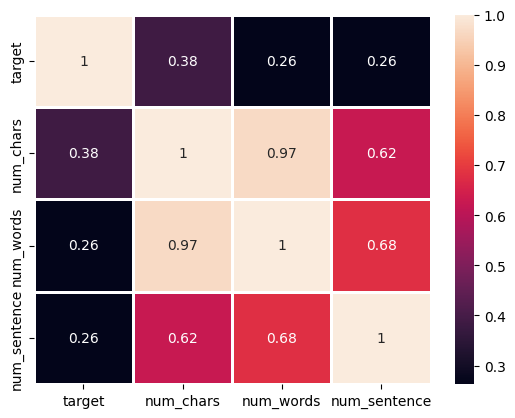

In [179]:
sns.heatmap(df[['target','num_chars','num_words','num_sentence']].corr(),annot=True,lw=2)

# data preprocessing
* lower case
* tokenization
* removing special characters
* removing stop words and punctuations
* stemming

In [180]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\naren\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [181]:
from nltk.corpus import stopwords
stopwords.words('english')

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [182]:
import string
punc=string.punctuation

In [183]:
from nltk.stem.porter import PorterStemmer
ps=PorterStemmer()

In [184]:
ps.stem('loving')

'love'

In [185]:
import re

In [186]:
def transform_text(text):
    text=text.lower()
    text=nltk.word_tokenize(text)

    # removing special char
    y=[]
    for i in text:
        y.extend(re.findall('[a-zA-Z0-9]+',i))
        # if i.isalnum():
        #     y.append(i)
    text=y.copy()
    y.clear()
    for i in text:
       if i not in  stopwords.words('english') and i not in string.punctuation: # punctuation not necessary here
           y.append(i)
    text=y.copy()
    y.clear()
    for i in text:
        y.append(ps.stem(i))
    return ' '.join(y)

In [187]:
transform_text('did loving eating dancing ? Hi  hello_..is my ringing.a!!!!. brother')

'love eat danc hi hello ring brother'

In [188]:
df['transformed_text']=df['text'].apply(lambda x:transform_text(x))

In [189]:
df.head()

,target,text,num_chars,num_words,num_sentence,transformed_text
0,0,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...",111,24,2,go jurong point crazi avail bugi n great world la e buffet cine got amor wat
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's,155,37,2,free entri 2 wkli comp win fa cup final tkt 21st may 2005 text fa 87121 receiv entri question std txt rate c appli 08452810075over18
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives around here though",61,15,1,nah n think goe usf live around though


In [190]:
from wordcloud import WordCloud
wc=WordCloud(width=500,height=500,min_font_size=10,background_color='white')

In [191]:
spam_wc=wc.generate(df[df['target']==1]['transformed_text'].str.cat(sep=' '))

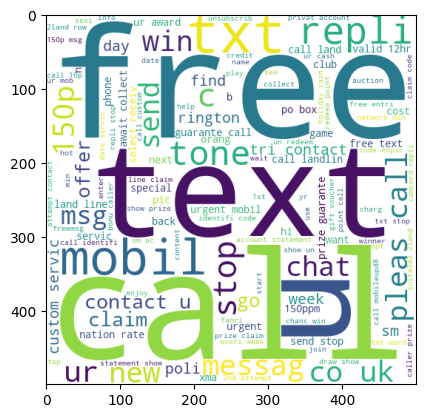

In [192]:
plt.imshow(spam_wc)

In [193]:
ham_wc=wc.generate(df[df['target']==0]['transformed_text'].str.cat(sep=' '))

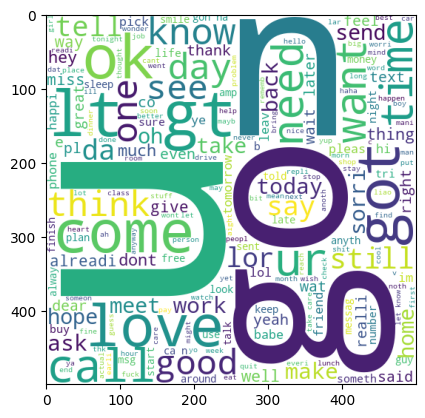

In [194]:
plt.imshow(ham_wc)

In [195]:
spam_corpus=[]
for msg in df[df['target']==1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)

In [196]:
len(spam_corpus)

11768

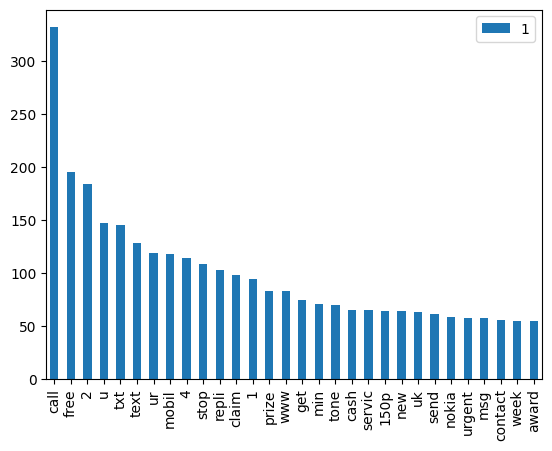

In [197]:
from collections import Counter
pd.DataFrame(Counter(spam_corpus).most_common(30)).plot(kind='bar')
plt.xticks(range(0,30),pd.DataFrame(Counter(spam_corpus).most_common(30))[0])
plt.show()

In [198]:
ham_corpus=[]
for msg in df[df['target']==0]['transformed_text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)

In [199]:
len(ham_corpus)

36746

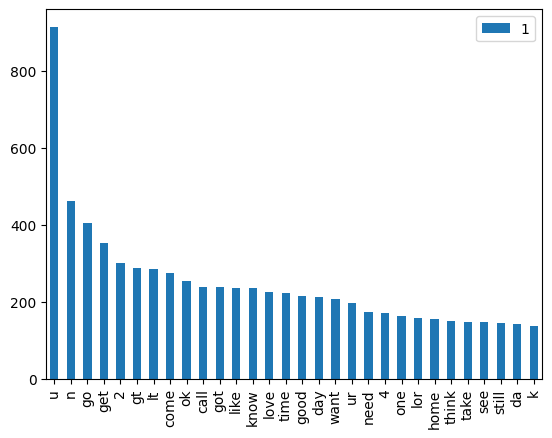

In [200]:
from collections import Counter
pd.DataFrame(Counter(ham_corpus).most_common(30)).plot(kind='bar')
plt.xticks(range(0,30),pd.DataFrame(Counter(ham_corpus).most_common(30))[0])
plt.show()

In [201]:
pd.DataFrame(Counter(ham_corpus).most_common(30))

,0,1
0,u,915
1,n,462
2,go,405
3,get,354
4,2,302
5,gt,288
6,lt,287
7,come,276
8,ok,255
9,call,240


In [202]:
df.head()

,target,text,num_chars,num_words,num_sentence,transformed_text
0,0,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...",111,24,2,go jurong point crazi avail bugi n great world la e buffet cine got amor wat
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's,155,37,2,free entri 2 wkli comp win fa cup final tkt 21st may 2005 text fa 87121 receiv entri question std txt rate c appli 08452810075over18
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives around here though",61,15,1,nah n think goe usf live around though


## **Model Building**

In [473]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv=CountVectorizer()
# tfidf=TfidfVectorizer()
tfidf=TfidfVectorizer(max_features=3000)


In [474]:
# x=cv.fit_transform(df['transformed_text']).toarray()
x2=tfidf.fit_transform(df['transformed_text']).toarray()

In [475]:
# x values scaling performance improving
# from sklearn.preprocessing import MinMaxScaler
# scaler=MinMaxScaler()
# x2=scaler.fit_transform(x2)

# no advantage ,instead precision got reduced

In [476]:
# appending the num_charcter col to x
# x2=np.hstack((x2,df['num_chars'].values.reshape(-1,1)))

In [477]:
x2

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(5169, 3000))

In [478]:
x2.shape

(5169, 3000)

In [479]:
y=df['target'].values

In [480]:
y

array([0, 0, 1, ..., 0, 0, 0], shape=(5169,))

In [481]:
from sklearn.model_selection import train_test_split


In [482]:
# x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [483]:
x2_train,x2_test,y_train,y_test=train_test_split(x2,y,test_size=0.2,random_state=42)

In [484]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [485]:
# precision score is most cared because we want our model not to do False positive
#---not spam marked as spam

In [486]:
# gnb=GaussianNB()
# mnb=MultinomialNB()
# bnb=BernoulliNB()

In [487]:
gnb2=GaussianNB()
mnb2=MultinomialNB()
bnb2=BernoulliNB()

In [401]:
# gnb.fit(x_train,y_train)
# y_pred1=gnb.predict(x_test)
# print(accuracy_score(y_test,y_pred1))
# print(confusion_matrix(y_test,y_pred1))
# print(precision_score(y_test,y_pred1))

In [402]:
gnb2.fit(x2_train,y_train)
y_pred1=gnb2.predict(x2_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

0.8820116054158608
[[783 106]
 [ 16 129]]
0.548936170212766


In [403]:
# mnb.fit(x_train,y_train)
# y_pred2=mnb.predict(x_test)
# print(accuracy_score(y_test,y_pred2))
# print(confusion_matrix(y_test,y_pred2))
# print(precision_score(y_test,y_pred2))

In [488]:
mnb2.fit(x2_train,y_train) # since high precision this model chosen
y_pred2=mnb2.predict(x2_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.9758220502901354
[[888   1]
 [ 24 121]]
0.9918032786885246


In [405]:
# bnb.fit(x_train,y_train)
# y_pred3=bnb.predict(x_test)
# print(accuracy_score(y_test,y_pred3))
# print(confusion_matrix(y_test,y_pred3))
# print(precision_score(y_test,y_pred3))

In [406]:
bnb2.fit(x2_train,y_train)
y_pred3=bnb2.predict(x2_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.9777562862669246
[[886   3]
 [ 20 125]]
0.9765625


In [407]:
# tfidf,mnb --> precision =1

In [408]:
# comparing mnb with other algos

In [409]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [410]:
# !pip install xgboost

In [411]:
svc=SVC(kernel='sigmoid',gamma=1.0)
knc=KNeighborsClassifier()
mnb=MultinomialNB()
dtc=DecisionTreeClassifier(max_depth=5)
lrc=LogisticRegression(solver='liblinear',penalty='l1')
rfc=RandomForestClassifier(n_estimators=50,random_state=42)
abc=AdaBoostClassifier(n_estimators=50,random_state=42)
bc=BaggingClassifier(n_estimators=50,random_state=42)
etc=ExtraTreesClassifier(n_estimators=50,random_state=42)
gbdt=GradientBoostingClassifier(n_estimators=50,random_state=42)
xgb=XGBClassifier(n_estimators=50,random_state=42)

In [412]:
clfs={
    'SVC':svc,
    'KN':knc,
    'NB':mnb,
    'DT':dtc,
    'LR':lrc,
    'RF':rfc,
    'AdaBoost':abc,
    'BgC':bc,
    'ETC':etc,
    'GBDT':gbdt,
    'xgb':xgb
}

In [413]:
def train_classifier(clf,x_train,y_train,x_test,y_test):
    clf.fit(x_train,y_train)
    y_pred=clf.predict(x_test)
    accuracy=accuracy_score(y_test,y_pred)
    precision=precision_score(y_test,y_pred)

    return accuracy,precision

In [319]:
train_classifier(svc,x2_train,y_train,x2_test,y_test)

(0.9777562862669246, 0.9621212121212122)

In [414]:
accuracy_scores=[]
precision_scores=[]
for name,clf in clfs.items():
    current_accuracy,current_precision=train_classifier(clf,x2_train,y_train,x2_test,y_test)

    print('for :',name)
    print('Accuracy -',current_accuracy)
    print('precision -',current_precision)

    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

for : SVC
Accuracy - 0.8597678916827853
precision - 0.0
for : KN
Accuracy - 0.8771760154738878
precision - 1.0
for : NB
Accuracy - 0.9738878143133463
precision - 0.9682539682539683
for : DT
Accuracy - 0.9448742746615088
precision - 0.9
for : LR
Accuracy - 0.9748549323017408
precision - 0.968503937007874
for : RF
Accuracy - 0.9796905222437138
precision - 0.984375
for : AdaBoost
Accuracy - 0.9448742746615088
precision - 0.8793103448275862
for : BgC
Accuracy - 0.9671179883945842
precision - 0.8881118881118881
for : ETC
Accuracy - 0.9835589941972921
precision - 0.9923076923076923
for : GBDT
Accuracy - 0.9545454545454546
precision - 0.9375
for : xgb
Accuracy - 0.9777562862669246
precision - 0.9485294117647058


In [ ]:
#when max_ feature is not used
# performance_df=pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_scores,'Precision':precision_scores}).sort_values('Precision',ascending=False)

In [257]:
performance_df

,Algorithm,Accuracy,Precision
1,KN,0.892650,1.000000
2,NB,0.966151,1.000000
8,ETC,0.978723,1.000000
5,RF,0.977756,0.991935
9,GBDT,0.962282,0.981818
0,SVC,0.974855,0.961240
10,xgb,0.978723,0.955556
7,BgC,0.976789,0.935252
3,DT,0.947776,0.917431
4,LR,0.952611,0.893443


In [258]:
performance_df1=performance_df.melt(id_vars=['Algorithm'],var_name='metric')

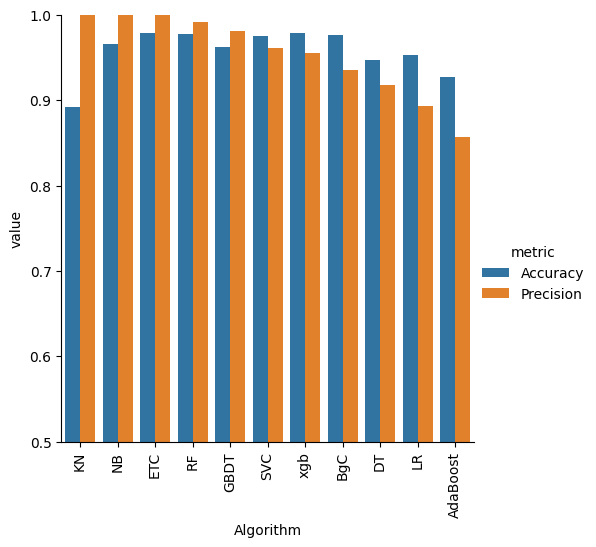

In [261]:
sns.catplot(x='Algorithm',y='value',hue='metric',data=performance_df1,kind='bar')
plt.ylim(0.5,1.0)
plt.xticks(rotation='vertical')
plt.show()

In [262]:
# model performance improvement

In [264]:
# 1.change te max_features parameter of Tfidf

# obtained best results at 3000 max_features

In [349]:
temp_df=pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_max_3000_features':accuracy_scores,'Precision_max_3000_features':precision_scores})

In [382]:
performance_df=performance_df.merge(temp_df,on='Algorithm')

In [385]:
# 2.scaling sparse input matrix
new_df=pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_scaling':accuracy_scores,'Precision_scaling':precision_scores})

In [416]:
performance_df=performance_df.merge(new_df,on='Algorithm')

In [ ]:
# no improvement by use of scaling precision got reduceed which should not be

In [417]:
 # 3.adding num_chars column
num_chars_df=pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_num_chars':accuracy_scores,'Precision_num_chars':precision_scores})

In [419]:
performance_df=performance_df.merge(num_chars_df,on='Algorithm')

In [420]:
# no use precision,accuracy reduced

In [421]:
# 4.voting classifier

svc=SVC(kernel='sigmoid',gamma=1.0,probability=True)
mnb=MultinomialNB()
etc=ExtraTreesClassifier(n_estimators=50,random_state=42)

from sklearn.ensemble import VotingClassifier

In [422]:
voting=VotingClassifier(estimators=[('svm',svc),('nb',mnb),('et',etc)],voting='soft')

In [424]:
voting.fit(x2_train,y_train)

,estimators,"[('svm', ...), ('nb', ...), ...]"
,voting,'soft'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,C,1.0
,kernel,'sigmoid'
,degree,3
,gamma,1.0
,coef0,0.0


In [426]:
y_pred=voting.predict(x2_test)
print('Accuracy',accuracy_score(y_test,y_pred))
print('Precision',precision_score(y_test,y_pred))

Accuracy 0.97678916827853
Precision 1.0


In [427]:
performance_df

,Algorithm,Accuracy,Precision,Accuracy_max_3000_features,Precision_max_3000_features,Accuracy_scaling,Precision_scaling,Accuracy_num_chars,Precision_num_chars
0,KN,0.892650,1.000000,0.902321,1.000000,0.899420,1.000000,0.877176,1.000000
1,NB,0.966151,1.000000,0.975822,0.991803,0.984526,0.977778,0.973888,0.968254
2,ETC,0.978723,1.000000,0.984526,0.992366,0.984526,0.992366,0.983559,0.992308
3,RF,0.977756,0.991935,0.982592,0.992248,0.982592,0.992248,0.979691,0.984375
4,GBDT,0.962282,0.981818,0.956480,0.990196,0.956480,0.990196,0.954545,0.937500
5,SVC,0.974855,0.961240,0.980658,0.969925,0.976789,0.954887,0.859768,0.000000
6,xgb,0.978723,0.955556,0.975822,0.954545,0.975822,0.954545,0.977756,0.948529
7,BgC,0.976789,0.935252,0.975822,0.916667,0.975822,0.916667,0.967118,0.888112
8,DT,0.947776,0.917431,0.943907,0.859504,0.945841,0.867769,0.944874,0.900000
9,LR,0.952611,0.893443,0.960348,0.912698,0.970986,0.967480,0.974855,0.968504


In [428]:
# 5.applying stacking
estimators=[('svm',svc),('nb',mnb),('et',etc)]
final_estimator=RandomForestClassifier()

In [429]:
from sklearn.ensemble import StackingClassifier

In [430]:
clf=StackingClassifier(estimators=estimators,final_estimator=final_estimator)

In [432]:
clf.fit(x2_train,y_train)
y_pred=clf.predict(x2_test)
print('Accuracy',accuracy_score(y_test,y_pred))
print('precision',precision_score(y_test,y_pred))

Accuracy 0.9825918762088974
precision 0.9568345323741008


In [ ]:
# finally using mnb 

In [ ]:
# test transform
# vectorize
# algorithm apply

In [445]:
import pickle
pickle.dump(tfidf,open('vectorizer.pkl','wb'))
pickle.dump(mnb2,open('model.pkl','wb'))

In [495]:
import matplotlib
import sklearn

In [496]:
print('numpy',np.__version__)
print('pandas',pd.__version__)
print('matplotlib',matplotlib.__version__)
print('seaborn',sns.__version__)
print('nltk',nltk.__version__)
print('scikit-learn',sklearn.__version__)

numpy 2.3.5
pandas 2.3.3
matplotlib 3.10.0
seaborn 0.13.2
nltk 3.9.2
scikit-learn 1.7.2


In [ ]:
numpy==2.3.5  pandas==2.3.3  matplotlib==3.10.0 seaborn==0.13.2 nltk==3.9.2 scikit-learn==1.7.2

In [497]:
import streamlit


In [498]:
streamlit.__version__


'1.51.0'